# Notebook 04: Evaluation and Visualization

## Project 19 - Anomaly Detection Using Autoencoders

**Pipeline stage:** 5 of 5 - Final Evaluation and Visualization

### Purpose

This notebook performs the final, comprehensive evaluation of the trained autoencoder models for anomaly detection on the KDD Cup 1999 dataset. It compares the baseline model against every model produced by the hyperparameter search in `03_hyperparameter_optimization.ipynb`, using consistent metrics and visualizations across all of them.

All metrics, tables, and plots are computed and rendered directly inline in this notebook. Running the notebook from top to bottom reproduces the complete evaluation.

### Anomaly Detection Methodology Note

For each model, the reconstruction error is computed as the mean squared error between the model's input and its reconstructed output. A decision threshold is calibrated at a chosen percentile of the *training-set* (normal-only) reconstruction-error distribution, and test samples whose reconstruction error exceeds that threshold are classified as anomalies. Standard classification metrics (accuracy, precision, recall, F1-score) are then computed against the ground-truth attack labels to quantify detection performance.

## 1. Environment Setup

Load the required libraries, add `src/` to the import path, and set the global reproducibility seed. This notebook is read-only with respect to the pipeline artifacts: it loads previously processed data and previously trained models but writes nothing back to disk.

In [1]:

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(str(Path.cwd().parent / 'src'))

from data_preprocessing import load_data, resolve_project_root
from evaluate import (
    calculate_reconstruction_error,
    select_anomaly_threshold,
    predict_anomalies,
    compute_anomaly_metrics,
    plot_reconstruction_error_distribution,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_reconstruction_error_vs_index,
    plot_threshold_sensitivity,
    plot_reconstruction_error_distribution_comparison,
    plot_confusion_matrix_comparison,
    plot_precision_recall_curve_comparison,
    plot_reconstruction_error_vs_index_comparison,
    plot_threshold_sensitivity_comparison,
    build_evaluation_report,
)
from model import build_autoencoder
from train import set_global_seed

# Global configuration
PERCENTILE = 95.0

# Set global seeds for reproducibility
set_global_seed(69)

# Initialize project paths (models/data are read-only inputs; nothing is written to disk)
project_root = resolve_project_root()
data_dir = project_root / "data" / "processed"
models_dir = project_root / "models"

print(f"Project Root: {project_root}")
print(f"Data Dir: {data_dir}")
print(f"Models Dir: {models_dir}")
print(f"Percentile: {PERCENTILE}")

Project Root: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection
Data Dir: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/data/processed
Models Dir: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/models
Percentile: 95.0


## 2. Data Loading

Load the preprocessed training and test arrays produced by `01_data_preprocessing.ipynb`. These are the same arrays used throughout the baseline and hyperparameter-search notebooks, ensuring a fair, consistent basis for comparing every model.

In [2]:
print("Loading data...")

# Load train and test tables
train_data_path = data_dir / "train.csv"
test_data_path = data_dir / "test.csv"

train_set = load_data(train_data_path)
test_set = load_data(test_data_path)

print("Train Set:")
display(train_set.head())
print("Test Set:")
display(test_set.head())

# Convert labels to numeric classes expected by sklearn metrics
label_to_int = {"normal": 0, "anomaly": 1}

feature_cols = [c for c in train_set.columns if c not in ["label", "binary_label"]]
X_train_df = train_set[feature_cols]
X_test_df = test_set[feature_cols]

y_train_series = train_set["binary_label"].map(label_to_int)
y_test_series = test_set["binary_label"].map(label_to_int)

if y_train_series.isna().any() or y_test_series.isna().any():
    raise ValueError("Unexpected values found in binary_label. Expected only 'normal' and 'anomaly'.")

# Default source: arrays built from CSV
X_train = X_train_df.to_numpy(dtype=np.float32)
X_test = X_test_df.to_numpy(dtype=np.float32)
y_train = y_train_series.to_numpy(dtype=np.int32)
y_test = y_test_series.to_numpy(dtype=np.int32)
source = "CSV-derived arrays"

print(f"Train Set Shape: {X_train.shape}, Labels Shape: {y_train.shape}")
print(f"Test Set Shape: {X_test.shape}, Labels Shape: {y_test.shape}")

Loading data...


Train Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.026526,-0.092098,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
1,-0.145561,-0.026472,-0.051431,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
2,-0.145561,-0.026689,-0.086207,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
3,-0.145561,-0.026173,-0.066131,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.025901,0.015446,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False


Test Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
1,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
2,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,True,False,False,False,False,False,False,False,False,False
3,-0.145561,-0.029163,-0.080533,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False


Train Set Shape: (61482, 118), Labels Shape: (61482,)
Test Set Shape: (84104, 118), Labels Shape: (84104,)


## 3. Model Loading and Comparison

Load every available trained model (the baseline model and each of the hyperparameter-search candidates) and evaluate them under an identical protocol: compute reconstruction errors, calibrate the anomaly threshold on the training set, generate test-set predictions, and compute classification metrics. All of these results are cached in `model_data` so that Sections 1 through 8 below can compare **every** model side-by-side. The single best-performing model (by F1-score) is also selected for the detailed architecture summary that follows.

Evaluating model: autoencoder_best_model_v2.keras


Evaluating model: autoencoder_best_model_v3.keras


Evaluating model: autoencoder_best_model_v1.keras


Evaluating model: autoencoder_baseline_model.keras


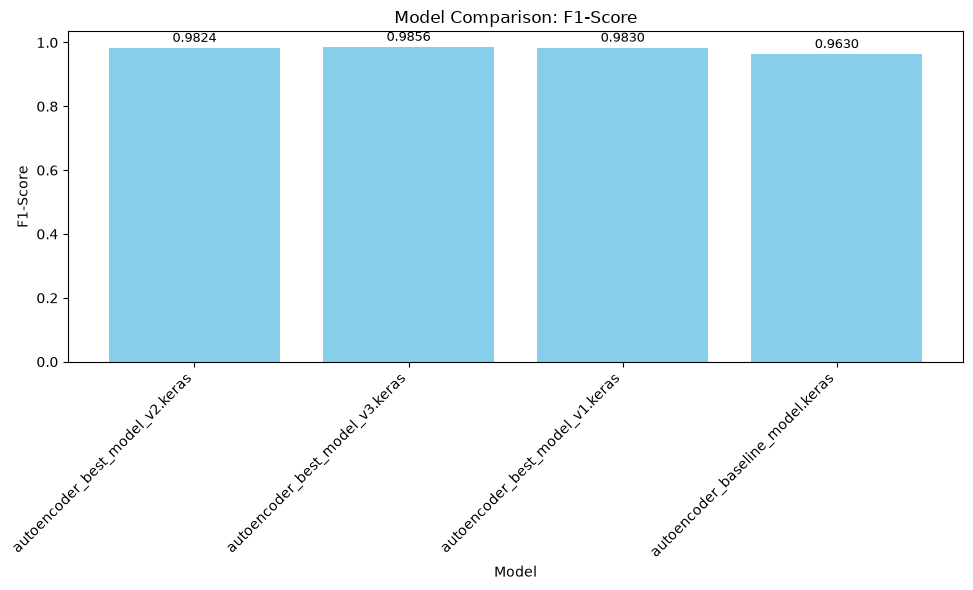


Selected best model for subsequent sections: autoencoder_best_model_v3.keras (F1-Score: 0.9856)


In [3]:
# Find all .keras files in the models directory and subdirectories
EXCLUDED_MODEL_FILENAMES = {'best_overall_model.keras'}
model_paths = [
    p for p in models_dir.rglob("*.keras")
    if p.name not in EXCLUDED_MODEL_FILENAMES
]
model_names = [str(p.relative_to(models_dir)) for p in model_paths]

# Sort models by name for consistent ordering
results = []
model_data = {}

for model_path, model_name in zip(model_paths, model_names):
    print(f"Evaluating model: {model_name}")
    try:
        m = tf.keras.models.load_model(model_path)

        # Compute reconstruction errors on training set
        train_errors = calculate_reconstruction_error(m, X_train)
        # Determine threshold using the specified percentile on training errors
        threshold = select_anomaly_threshold(train_errors, percentile=PERCENTILE)

        # Compute reconstruction errors on test set
        test_errors = calculate_reconstruction_error(m, X_test)
        # Predict anomalies on test set
        y_pred = predict_anomalies(test_errors, threshold)

        # Compute metrics
        metrics = compute_anomaly_metrics(y_test, y_pred)

        # Store summary results
        results.append({
            'model_name': model_name,
            'model_path': str(model_path),
            'threshold': threshold,
            'accuracy': metrics['accuracy'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1_score': metrics['f1_score'],
            'confusion_matrix': metrics['confusion_matrix']
        })

        # Store everything needed for the per-model comparisons in sections 1-8
        model_data[model_name] = {
            'model_path': model_path,
            'train_errors': train_errors,
            'test_errors': test_errors,
            'threshold': threshold,
            'y_pred': y_pred,
            'y_test': y_test,
            'metrics': metrics,
        }
    except Exception as e:
        print(f"Error evaluating model {model_name}: {e}")
        # Store NaN values for failed models
        results.append({
            'model_name': model_name,
            'model_path': str(model_path),
            'threshold': np.nan,
            'accuracy': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1_score': np.nan,
            'confusion_matrix': None
        })

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(results)

# Identify the baseline model
baseline_model_name = 'autoencoder_baseline_model.keras'
baseline_result = results_df[results_df['model_name'] == baseline_model_name]
if not baseline_result.empty:
    baseline_metrics = baseline_result.iloc[0]
    # Calculate improvement over baseline for each model
    results_df['accuracy_improvement'] = results_df['accuracy'] - baseline_metrics['accuracy']
    results_df['precision_improvement'] = results_df['precision'] - baseline_metrics['precision']
    results_df['recall_improvement'] = results_df['recall'] - baseline_metrics['recall']
    results_df['f1_score_improvement'] = results_df['f1_score'] - baseline_metrics['f1_score']
else:
    # If baseline not found, set improvements to NaN
    results_df['accuracy_improvement'] = np.nan
    results_df['precision_improvement'] = np.nan
    results_df['recall_improvement'] = np.nan
    results_df['f1_score_improvement'] = np.nan
    print(f"Warning: Baseline model '{baseline_model_name}' not found in models directory.")


# Plot a bar chart comparing F1 scores
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(results_df)), results_df['f1_score'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.title('Model Comparison: F1-Score')
plt.xticks(range(len(results_df)), results_df['model_name'], rotation=45, ha='right')
# Add value labels on top of bars
for bar, f1 in zip(bars, results_df['f1_score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{f1:.4f}', 
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Select the best model based on F1-score for use in the subsequent sections
if not results_df['f1_score'].isna().all():
    best_model_idx = results_df['f1_score'].idxmax()
    best_model_name = results_df.loc[best_model_idx, 'model_name']
    best_model_path = results_df.loc[best_model_idx, 'model_path']
    model = tf.keras.models.load_model(best_model_path)
    print(f"\nSelected best model for subsequent sections: {best_model_name} (F1-Score: {results_df.loc[best_model_idx, 'f1_score']:.4f})")
else:
    # Fallback to the original method of loading the best_optimized_model
    best_model_path = models_dir / 'best_optimized_model.keras'
    if best_model_path.exists():
        model = tf.keras.models.load_model(best_model_path)
        best_model_name = str(best_model_path.relative_to(models_dir))
        print(f"\nFallback to best_optimized_model: {best_model_path}")
    else:
        # Try to load any model
        for model_path, model_name in zip(model_paths, model_names):
            if model_path.exists():
                model = tf.keras.models.load_model(model_path)
                best_model_path = model_path
                best_model_name = model_name
                print(f"\nFallback to first available model: {model_path}")
                break
        else:
            raise FileNotFoundError("No model found in models directory.")

In [4]:
# Show the architecture of the model selected above for the detailed analysis below
print(f"Using model: {best_model_name}")
model.summary()

Using model: autoencoder_best_model_v3.keras


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 118)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 64)             │        23,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 118)            │        23,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,092 (551.14 KB)

 Trainable params: 47,030 (183.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 94,062 (367.43 KB)

## 4. Threshold Calibration and Metrics Computation

This section compares the calibrated anomaly threshold and evaluation metrics for **every** model in a single summary table, ranked by F1-score, to identify the overall best-performing configuration.

In [5]:
# Single comparison table built from the per-model data cached in model_data
threshold_metrics_df = pd.DataFrame([
    {
        'model_name': model_name,
        'threshold': data['threshold'],
        'accuracy': data['metrics']['accuracy'],
        'precision': data['metrics']['precision'],
        'recall': data['metrics']['recall'],
        'f1_score': data['metrics']['f1_score'],
    }
    for model_name, data in model_data.items()
]).sort_values('f1_score', ascending=False).reset_index(drop=True)

display(threshold_metrics_df)

top_model_name = threshold_metrics_df.iloc[0]['model_name']
print(f"\nTop model by F1-Score: {top_model_name} (F1={threshold_metrics_df.iloc[0]['f1_score']:.6f})")

,model_name,threshold,accuracy,precision,recall,f1_score
0,autoencoder_best_model_v3.keras,0.001488,0.980096,0.978090,0.993265,0.985619
1,autoencoder_best_model_v1.keras,0.013061,0.976541,0.977553,0.988538,0.983014
2,autoencoder_best_model_v2.keras,0.011223,0.975756,0.977593,0.987326,0.982435
3,autoencoder_baseline_model.keras,0.892315,0.949955,0.977152,0.949320,0.963035



Top model by F1-Score: autoencoder_best_model_v3.keras (F1=0.985619)


## 5. Error Statistics and Distribution Analysis

This section summarizes reconstruction-error statistics for every model in a single table, then visualizes the reconstruction-error distribution as a two-class histogram: normal traffic (training data plus the normal portion of the test set) versus attack traffic (the anomalous portion of the test set). Errors are plotted on a log-scaled x-axis with a dashed line marking the calibrated decision threshold, first as a side-by-side comparison across all models and then as an individual full-size plot for each model.

,model_name,threshold,train_mean,train_std,test_normal_mean,test_anomaly_mean,pct_train_above_thresh,pct_test_normal_above_thresh,pct_test_anomaly_above_thresh
0,autoencoder_best_model_v2.keras,0.011223,0.003813,0.212460,0.006819,0.544464,5.001464,4.960152,98.732555
1,autoencoder_best_model_v3.keras,0.001488,0.001167,0.076544,0.001579,0.488181,5.001464,4.876660,99.326454
2,autoencoder_best_model_v1.keras,0.013061,0.003470,0.078175,0.007527,0.507802,5.001464,4.975332,98.853759
3,autoencoder_baseline_model.keras,0.892315,0.287070,4.274499,0.334950,98.602196,5.001464,4.865275,94.931953


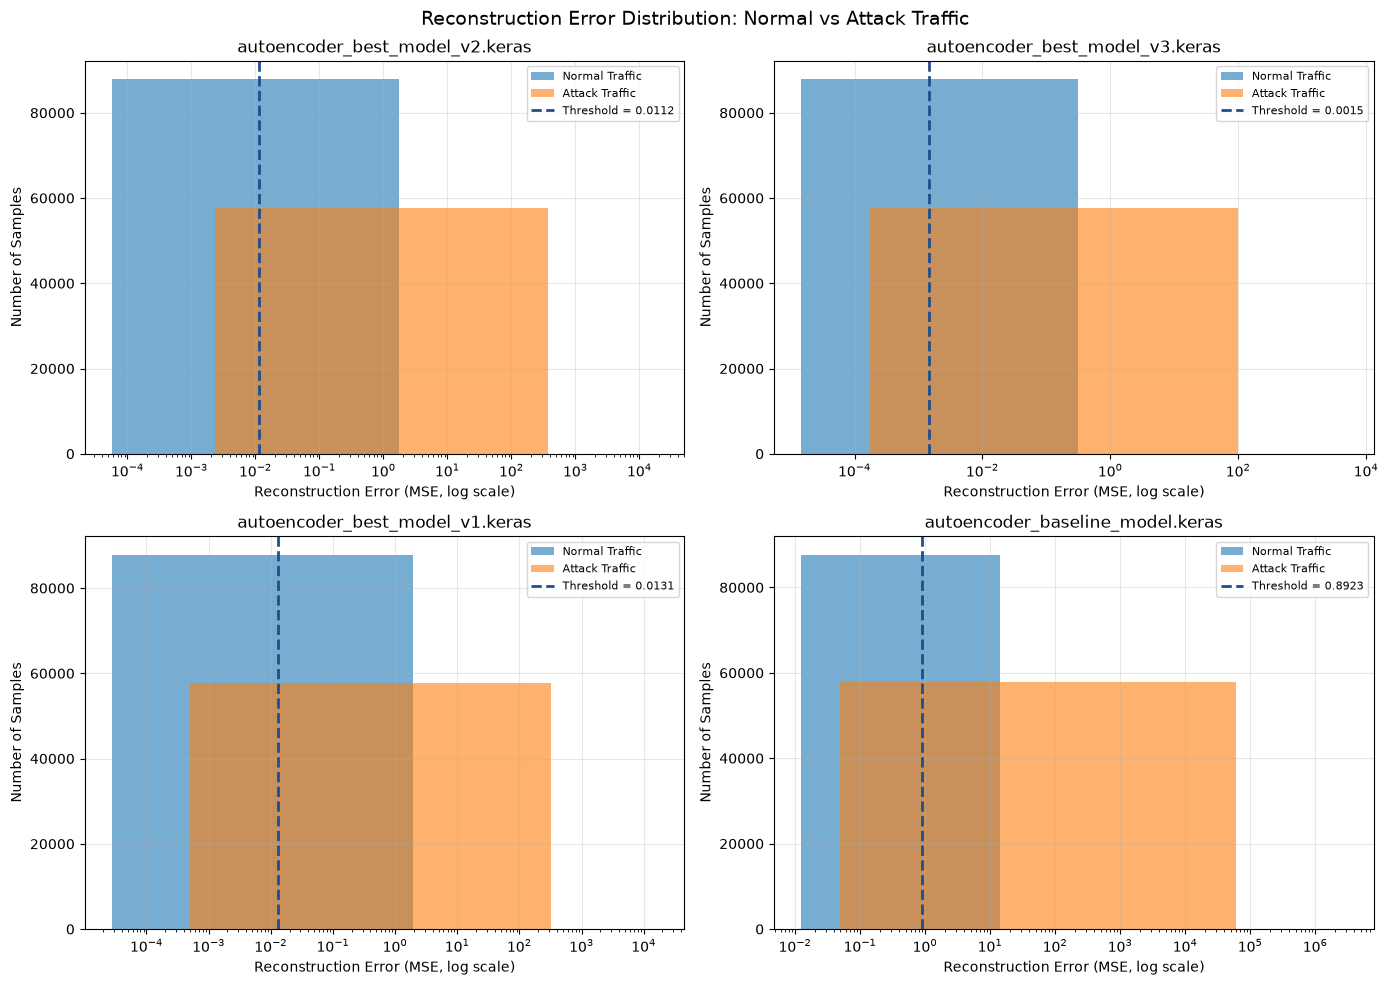


--- autoencoder_best_model_v2.keras ---


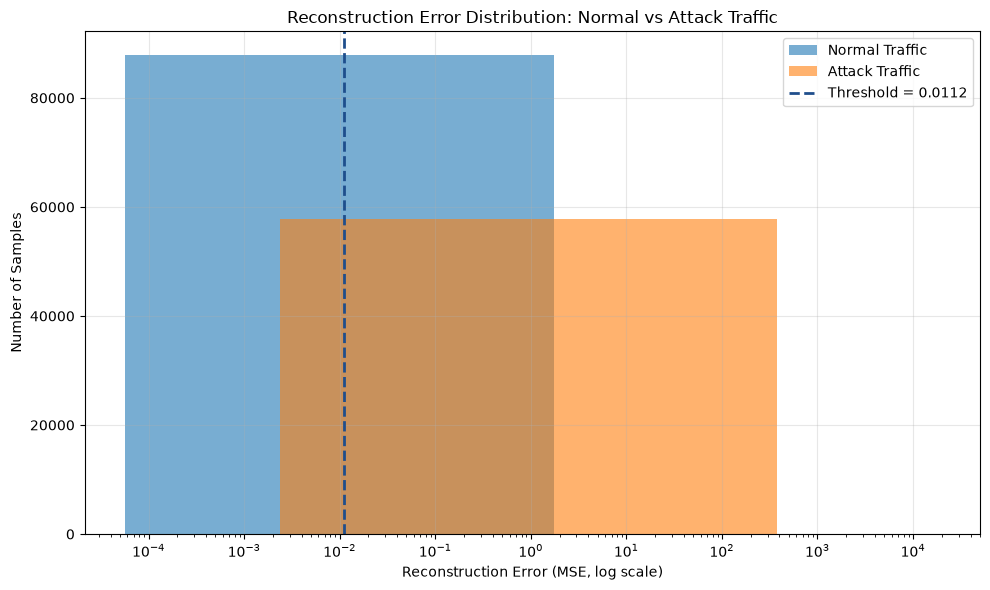


--- autoencoder_best_model_v3.keras ---


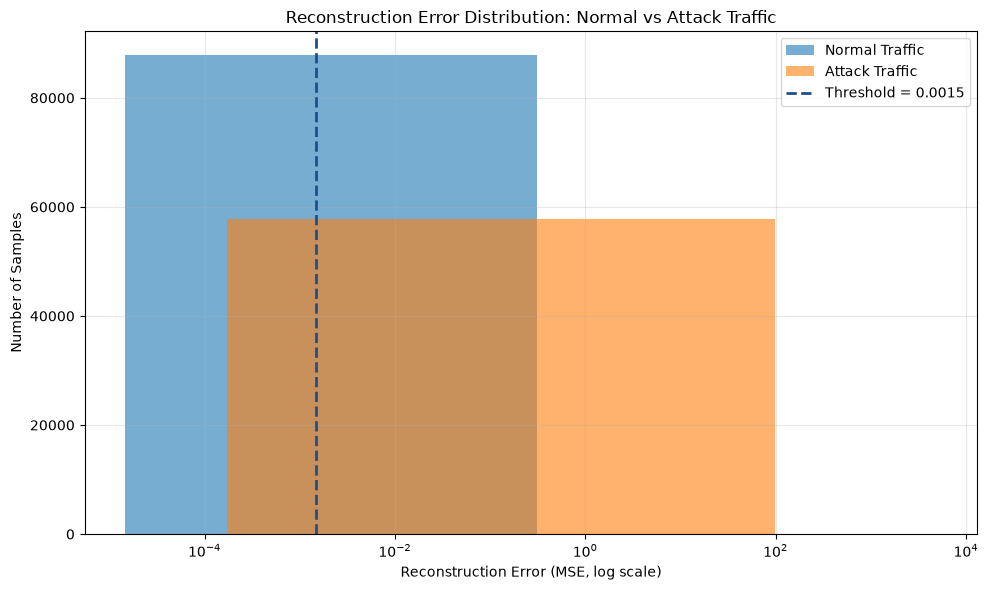


--- autoencoder_best_model_v1.keras ---


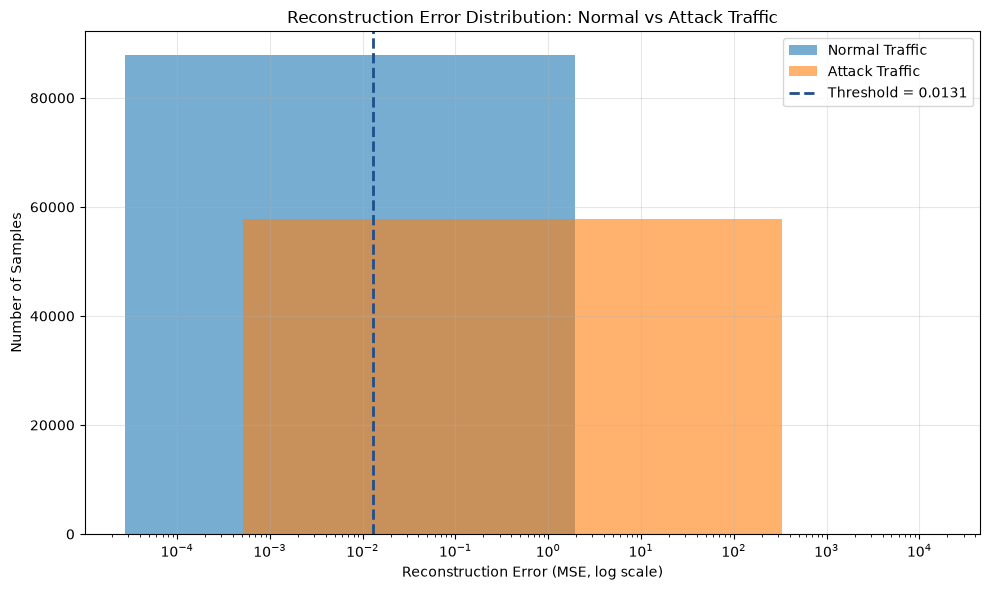


--- autoencoder_baseline_model.keras ---


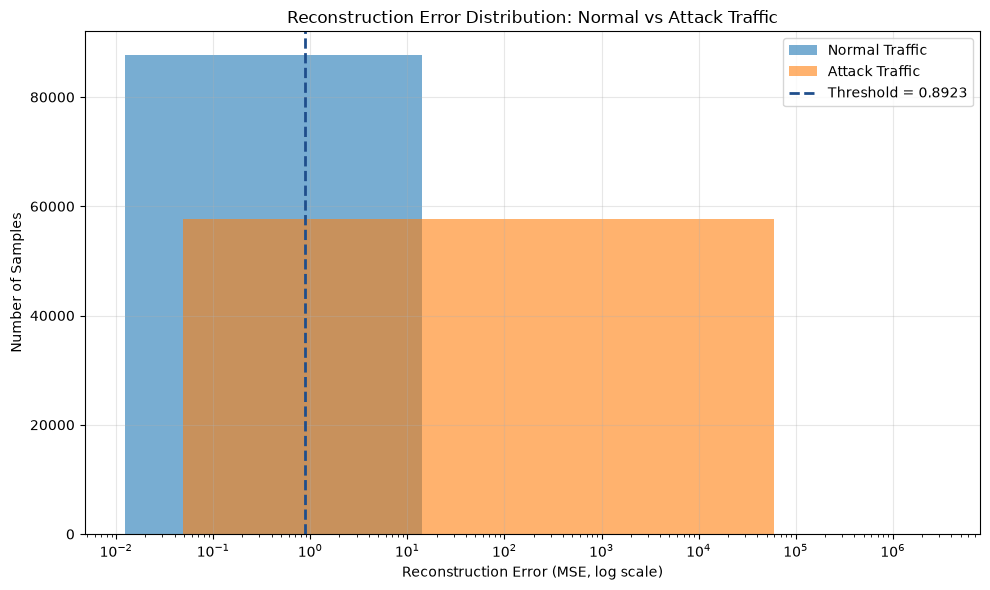

In [6]:
# Single summary table of reconstruction error statistics for every model
error_stats_rows = []
for model_name, data in model_data.items():
    train_errors = data['train_errors']
    test_errors = data['test_errors']
    y_test_m = data['y_test']
    threshold = data['threshold']
    test_normal = test_errors[y_test_m == 0]
    test_anomaly = test_errors[y_test_m == 1]

    error_stats_rows.append({
        'model_name': model_name,
        'threshold': threshold,
        'train_mean': np.mean(train_errors),
        'train_std': np.std(train_errors),
        'test_normal_mean': np.mean(test_normal),
        'test_anomaly_mean': np.mean(test_anomaly),
        'pct_train_above_thresh': 100 * np.mean(train_errors > threshold),
        'pct_test_normal_above_thresh': 100 * np.mean(test_normal > threshold),
        'pct_test_anomaly_above_thresh': 100 * np.mean(test_anomaly > threshold),
    })

error_stats_df = pd.DataFrame(error_stats_rows)
display(error_stats_df)

# Single comparison figure: one distribution subplot per model
plot_reconstruction_error_distribution_comparison(model_data)

# Individual full-size distribution plot for each model
for model_name, data in model_data.items():
    print(f"\n--- {model_name} ---")
    plot_reconstruction_error_distribution(
        train_errors=data['train_errors'],
        test_errors=data['test_errors'],
        y_test=data['y_test'],
        threshold=data['threshold'],
    )

## 6. Confusion Matrix

This section visualizes the confusion matrix as a heatmap for every model, arranged side-by-side in a single comparison figure, plus each model's individual full-size heatmap.

,model_name,TN,FP,FN,TP
0,autoencoder_best_model_v2.keras,25043,1307,732,57022
1,autoencoder_best_model_v3.keras,25065,1285,389,57365
2,autoencoder_best_model_v1.keras,25039,1311,662,57092
3,autoencoder_baseline_model.keras,25068,1282,2927,54827


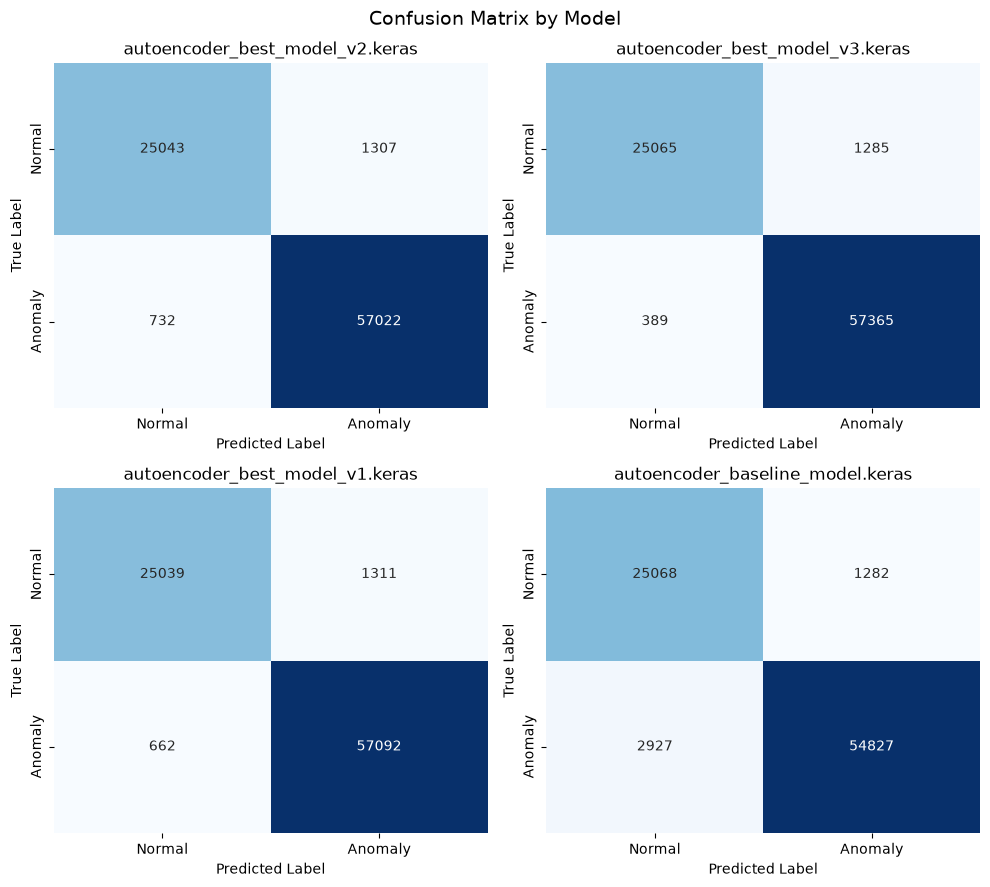


--- autoencoder_best_model_v2.keras ---


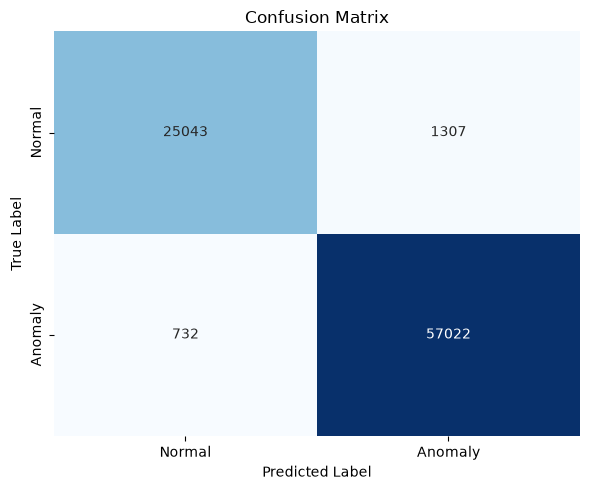


--- autoencoder_best_model_v3.keras ---


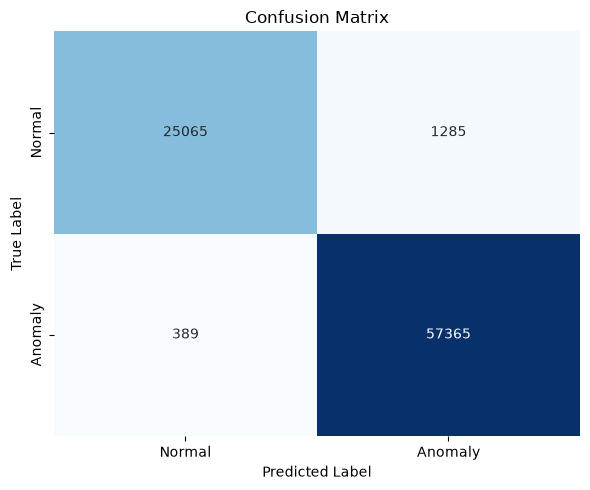


--- autoencoder_best_model_v1.keras ---


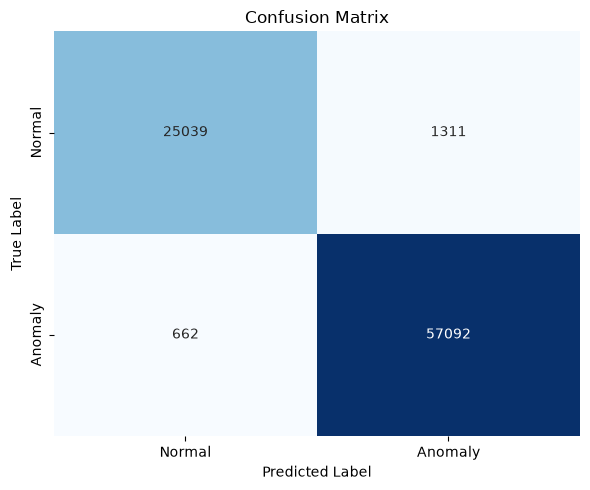


--- autoencoder_baseline_model.keras ---


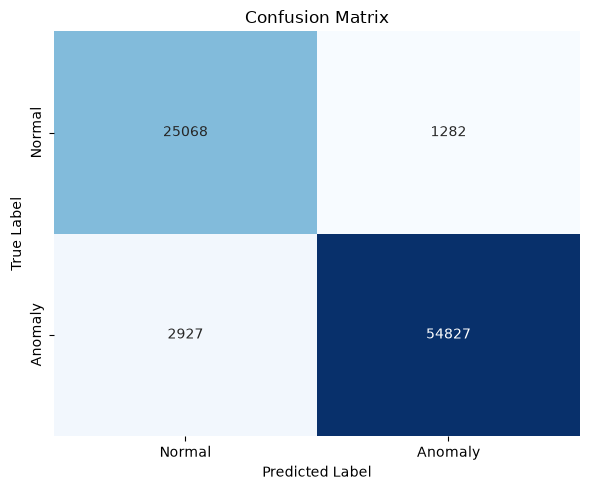

In [7]:
# Single summary table of TN/FP/FN/TP counts for every model
cm_rows = []
cms_by_model = {}
for model_name, data in model_data.items():
    cm = data['metrics']['confusion_matrix']
    cms_by_model[model_name] = cm
    tn, fp, fn, tp = cm.ravel()
    cm_rows.append({'model_name': model_name, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp})

display(pd.DataFrame(cm_rows))

# Single comparison figure: one confusion matrix heatmap per model
plot_confusion_matrix_comparison(cms_by_model)

# Individual full-size confusion matrix heatmap for each model
for model_name, cm in cms_by_model.items():
    print(f"\n--- {model_name} ---")
    plot_confusion_matrix(cm)

## 7. Precision-Recall Curve

This section overlays the precision-recall curve for every model on a single comparison plot, using reconstruction errors as anomaly scores, plus each model's individual full-size PR curve. Each model's current operating point (i.e., its calibrated threshold) is marked on its curve.

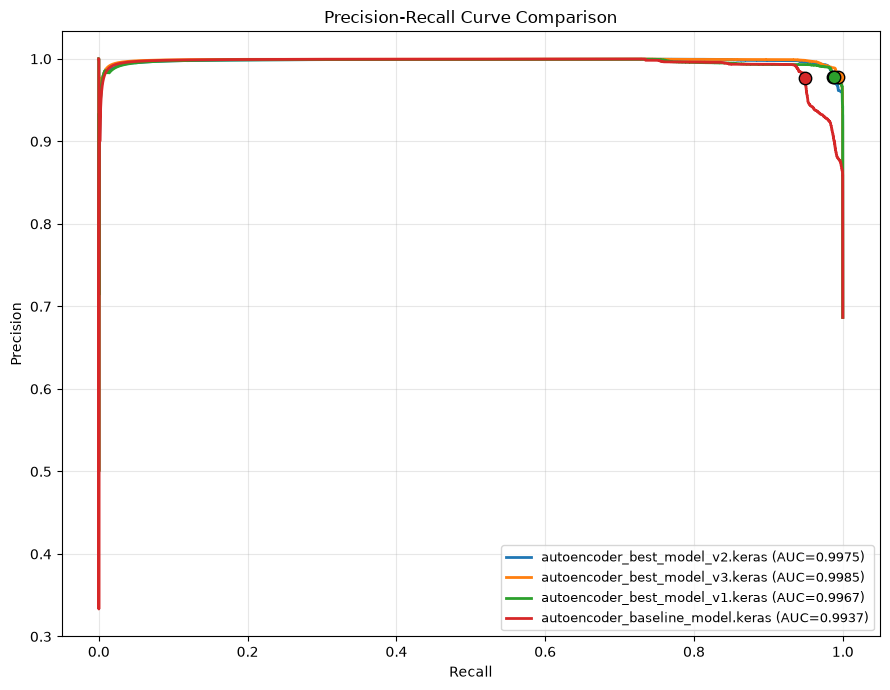


--- autoencoder_best_model_v2.keras ---


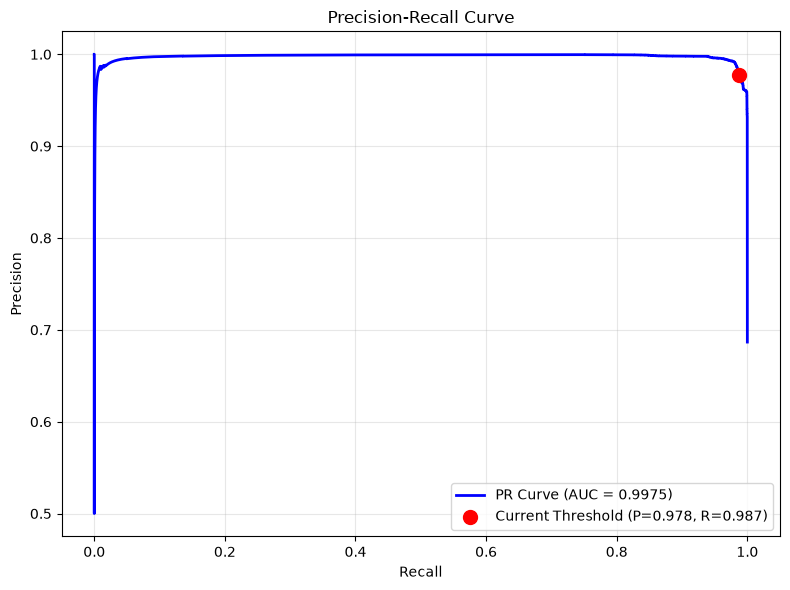


--- autoencoder_best_model_v3.keras ---


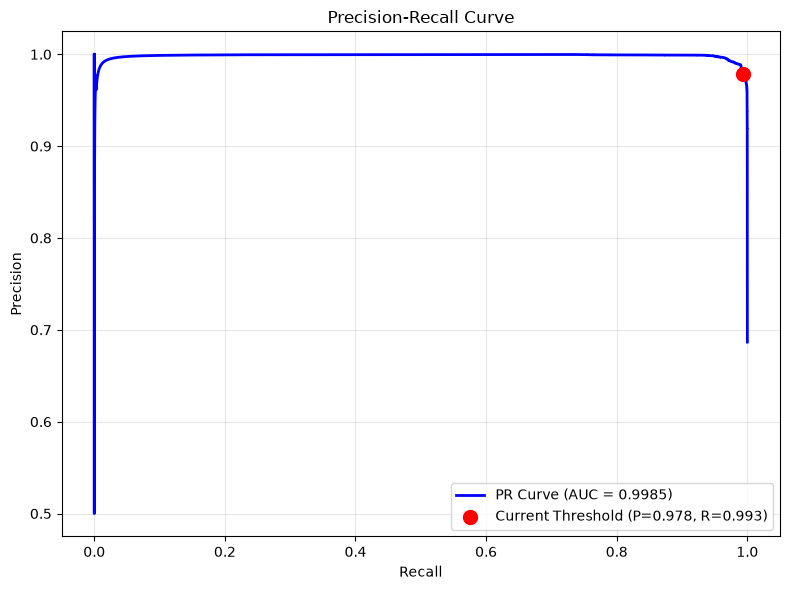


--- autoencoder_best_model_v1.keras ---


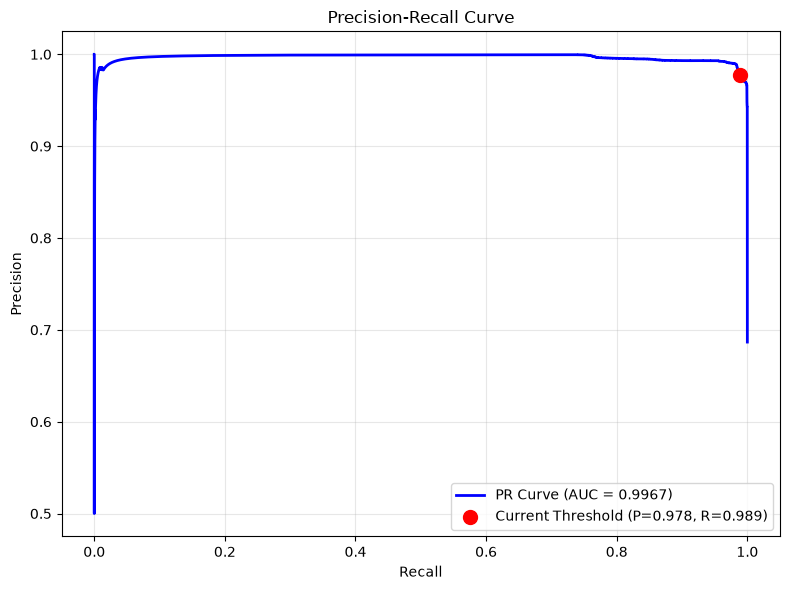


--- autoencoder_baseline_model.keras ---


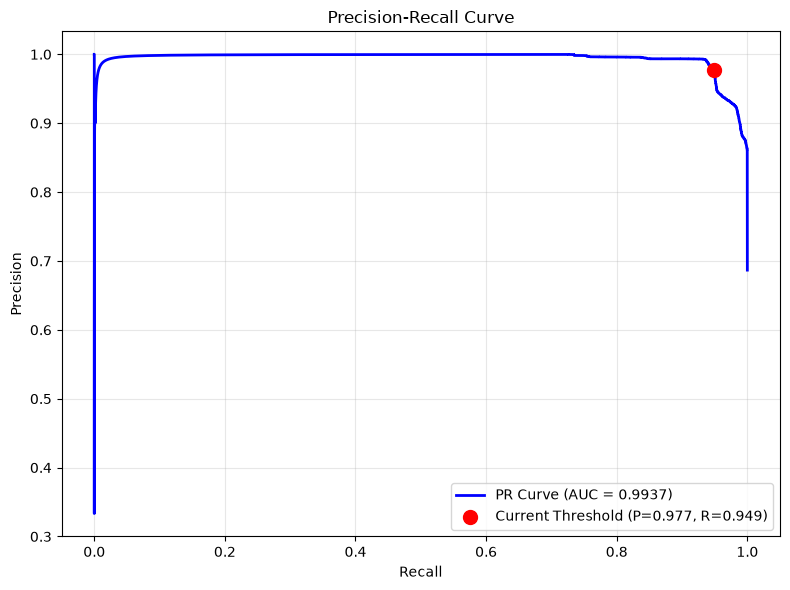

In [8]:
# Single overlay figure comparing PR curves across all models
plot_precision_recall_curve_comparison(
    y_test=y_test,
    model_errors=model_data,
)

# Individual full-size PR curve for each model
for model_name, data in model_data.items():
    print(f"\n--- {model_name} ---")
    plot_precision_recall_curve(
        y_test=y_test,
        test_errors=data['test_errors'],
        threshold=data['threshold'],
    )

## 8. Reconstruction Error vs. Sample Index

This section produces a scatter plot of reconstruction error versus sample index for every model, with predicted anomalies highlighted in red and the calibrated threshold line shown, arranged in a single comparison grid figure, plus each model's individual full-size scatter plot.

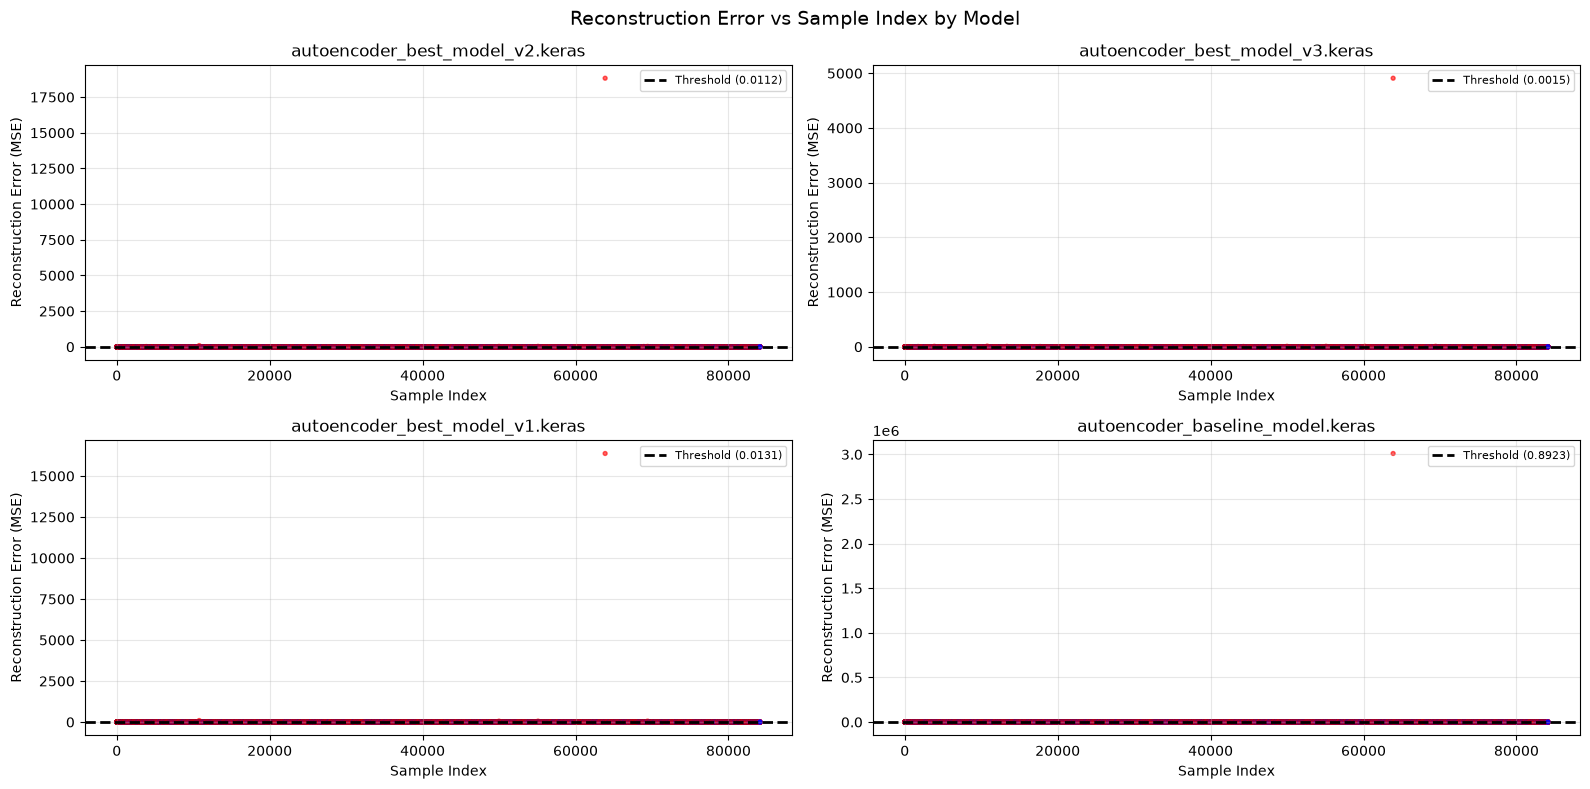


--- autoencoder_best_model_v2.keras ---


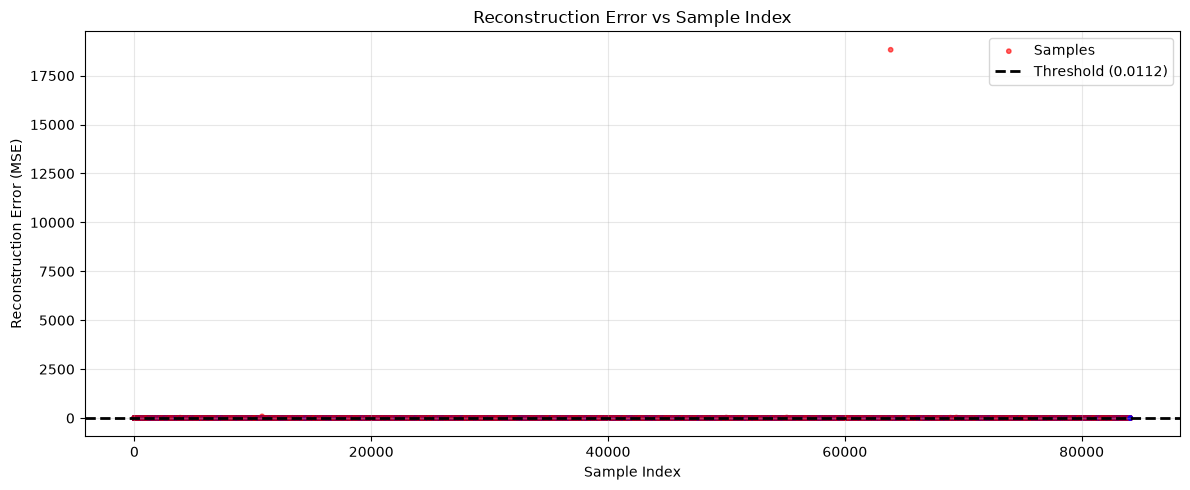


--- autoencoder_best_model_v3.keras ---


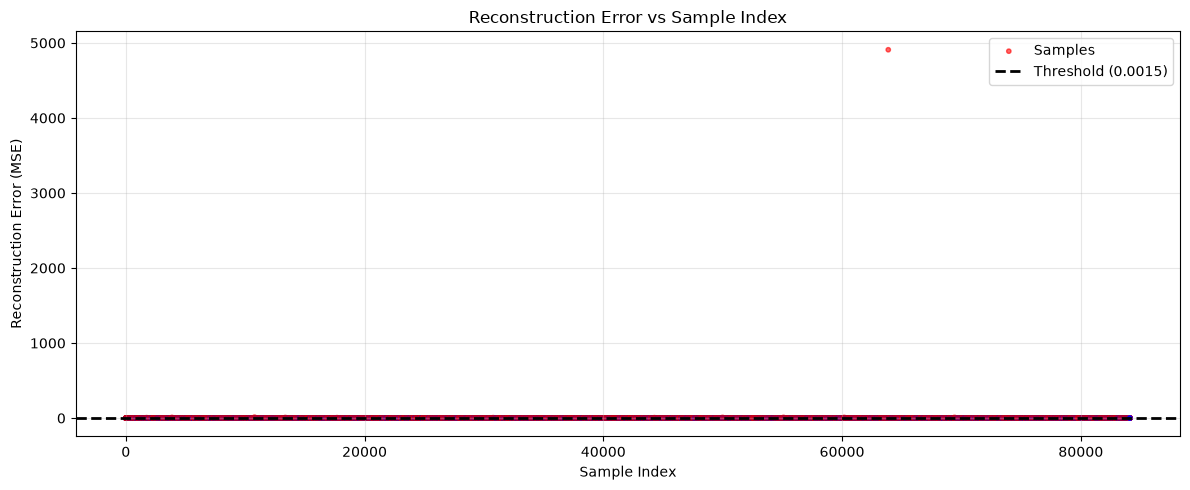


--- autoencoder_best_model_v1.keras ---


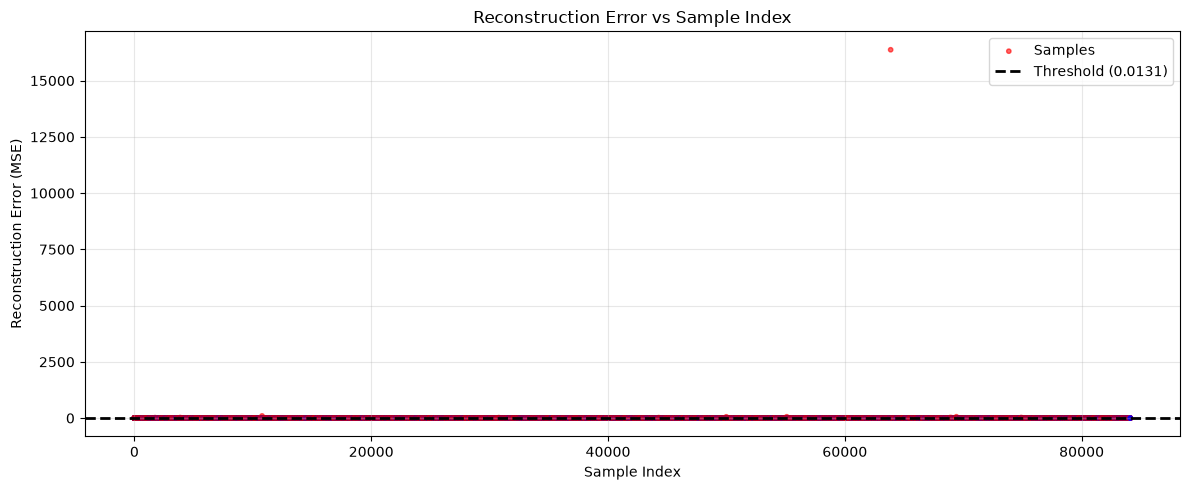


--- autoencoder_baseline_model.keras ---


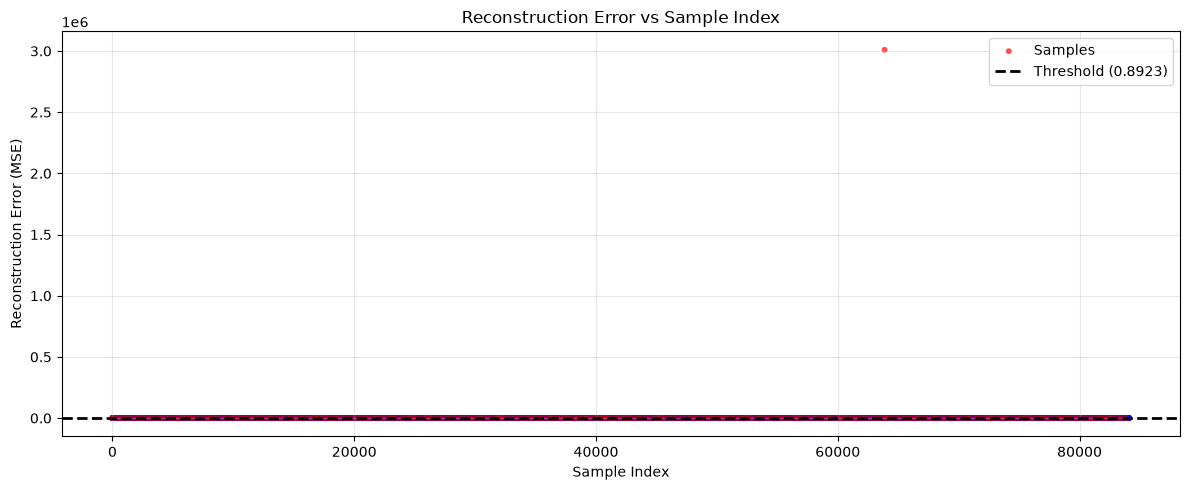

In [9]:
# Single comparison figure: one scatter plot per model
plot_reconstruction_error_vs_index_comparison(model_data)

# Individual full-size scatter plot for each model
for model_name, data in model_data.items():
    print(f"\n--- {model_name} ---")
    plot_reconstruction_error_vs_index(
        test_errors=data['test_errors'],
        y_pred=data['y_pred'],
        threshold=data['threshold'],
    )

## 9. Comprehensive Report

This section generates a single comprehensive evaluation report containing the metrics, threshold, and confusion-matrix details for every model, ranked by F1-score, suitable for direct inclusion in the final project report.

In [10]:
# Rank models by F1-score, then build a single combined report string
models_by_f1 = sorted(
    model_data.items(), key=lambda kv: kv[1]['metrics']['f1_score'], reverse=True
)

report_sections = []
for model_name, data in models_by_f1:
    header = f"MODEL: {model_name}"
    report_sections.append(header + "\n" + "#" * len(header))
    report_sections.append(
        build_evaluation_report(
            metrics=data['metrics'],
            threshold=data['threshold'],
            percentile=PERCENTILE,
        )
    )

combined_report_text = "\n\n".join(report_sections)
print(combined_report_text)

MODEL: autoencoder_best_model_v3.keras
######################################

AUTOENCODER ANOMALY DETECTION - EVALUATION REPORT

Threshold Percentile: 95.0
Anomaly Threshold:    0.00148778

CLASSIFICATION METRICS
------------------------------
Accuracy:  0.980096
Precision: 0.978090
Recall:    0.993265
F1-Score:  0.985619

CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     26350
           1       0.98      0.99      0.99     57754

    accuracy                           0.98     84104
   macro avg       0.98      0.97      0.98     84104
weighted avg       0.98      0.98      0.98     84104


CONFUSION MATRIX
------------------------------
[[25065  1285]
 [  389 57365]]

End of Report


MODEL: autoencoder_best_model_v1.keras
######################################

AUTOENCODER ANOMALY DETECTION - EVALUATION REPORT

Threshold Percentile: 95.0
Anomaly Threshold:    0.01306058

CLASSI

## 10. Per-Class / Per-Attack Analysis

This section analyzes detection performance broken down by individual attack category (rather than the aggregate binary normal/anomaly label) for every model, and presents the per-attack detection rates for all models side-by-side in a single pivot table. This reveals whether certain attack families (e.g., U2R, which is rare and behaviorally similar to normal traffic) are systematically harder to detect than others.

In [11]:
# Load original categorical labels from the test set
test_labels_categorical = test_set['label'].values
unique_attacks = np.unique(test_labels_categorical)

print(f"Unique attack types in test set: {unique_attacks}")
print(f"Count per type:\n{pd.Series(test_labels_categorical).value_counts()}")


def _detection_rate(attack, y_pred_attack):
    # For normal class, we want 0 predictions (correct = normal)
    # For attack classes, we want 1 predictions (correct = anomaly)
    correct_label = 0 if attack == 'normal' else 1
    total = len(y_pred_attack)
    correct = int(np.sum(y_pred_attack == correct_label))
    return correct / total if total > 0 else np.nan


# Compute per-attack detection rates for every model
per_attack_rows = []
for attack in unique_attacks:
    mask = (test_labels_categorical == attack)
    row = {'attack': attack, 'type': 'normal' if attack == 'normal' else 'attack', 'total': int(np.sum(mask))}
    for model_name, data in model_data.items():
        row[model_name] = _detection_rate(attack, data['y_pred'][mask])
    per_attack_rows.append(row)

# Single pivot table: rows = attack type, columns = detection rate per model
per_attack_df = pd.DataFrame(per_attack_rows)
print(f"\nPercentile: {PERCENTILE} (per-model thresholds shown in Section 1)\n")
display(per_attack_df)

Unique attack types in test set: ['back' 'buffer_overflow' 'ftp_write' 'guess_passwd' 'imap' 'ipsweep'
 'land' 'loadmodule' 'multihop' 'neptune' 'nmap' 'normal' 'perl' 'phf'
 'pod' 'portsweep' 'rootkit' 'satan' 'smurf' 'spy' 'teardrop'
 'warezclient' 'warezmaster']
Count per type:
neptune            51820
normal             26350
back                 968
teardrop             918
satan                906
warezclient          893
ipsweep              651
smurf                641
portsweep            416
pod                  206
nmap                 158
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  19
imap                  12
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Percentile: 95.0 (per-model thresholds shown in Section 1)



,attack,type,total,autoencoder_best_model_v2.keras,autoencoder_best_model_v3.keras,autoencoder_best_model_v1.keras,autoencoder_baseline_model.keras
0,back,attack,968,0.793388,1.000000,0.851240,0.013430
1,buffer_overflow,attack,30,0.800000,0.800000,0.800000,0.733333
2,ftp_write,attack,8,0.750000,0.750000,0.750000,0.500000
3,guess_passwd,attack,53,1.000000,1.000000,1.000000,1.000000
4,imap,attack,12,1.000000,1.000000,1.000000,0.916667
5,ipsweep,attack,651,1.000000,1.000000,1.000000,0.861751
6,land,attack,19,1.000000,1.000000,1.000000,1.000000
7,loadmodule,attack,9,1.000000,1.000000,1.000000,0.666667
8,multihop,attack,7,1.000000,0.857143,1.000000,0.857143
9,neptune,attack,51820,1.000000,1.000000,1.000000,0.999961


## 11. Threshold Sensitivity Analysis

This final section analyzes how the evaluation metrics change across different threshold percentiles for every model, in order to understand the precision-recall trade-off implied by the choice of threshold. Results are overlaid in a single comparison figure, plus each model's individual full-size sensitivity plot. This analysis illustrates that the percentile chosen for anomaly thresholding is a tunable operating point, not a fixed property of the model.

Computing threshold sensitivity for all models...


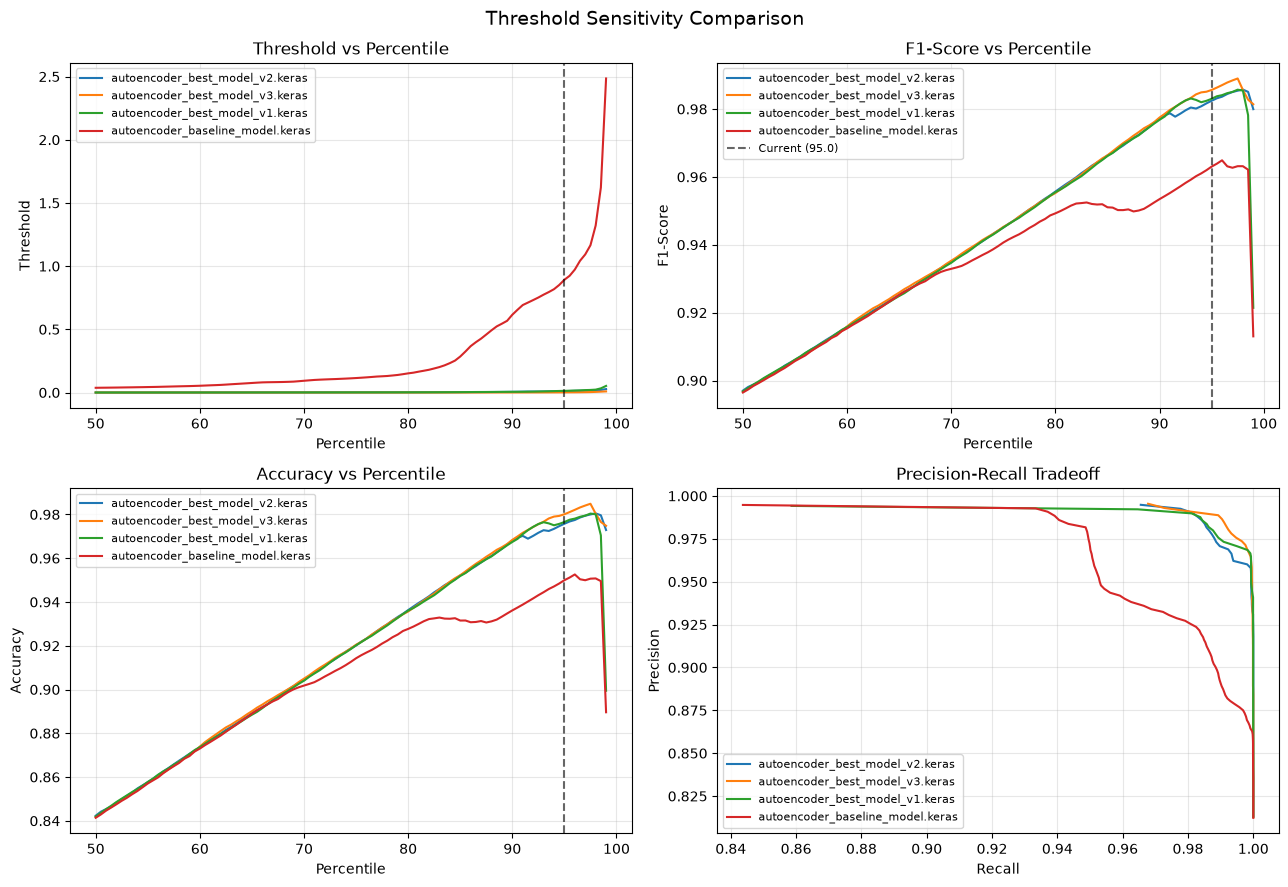


--- autoencoder_best_model_v2.keras ---


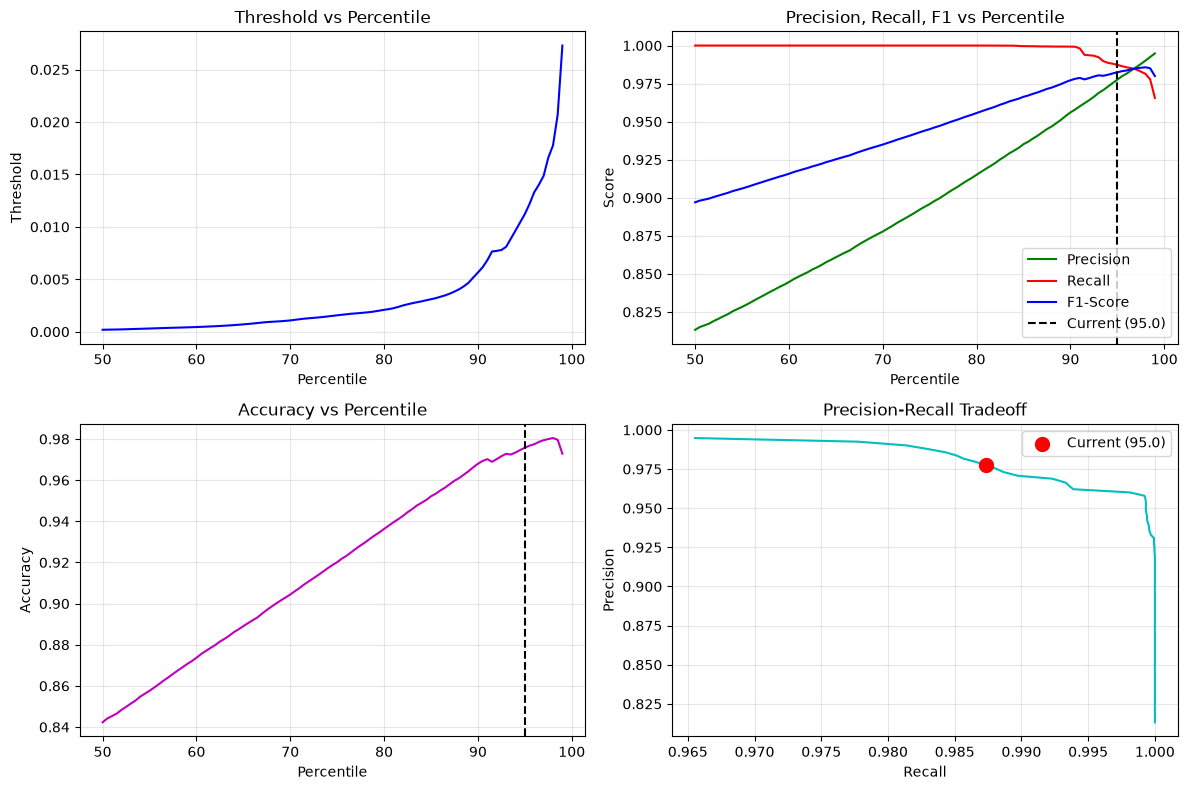


--- autoencoder_best_model_v3.keras ---


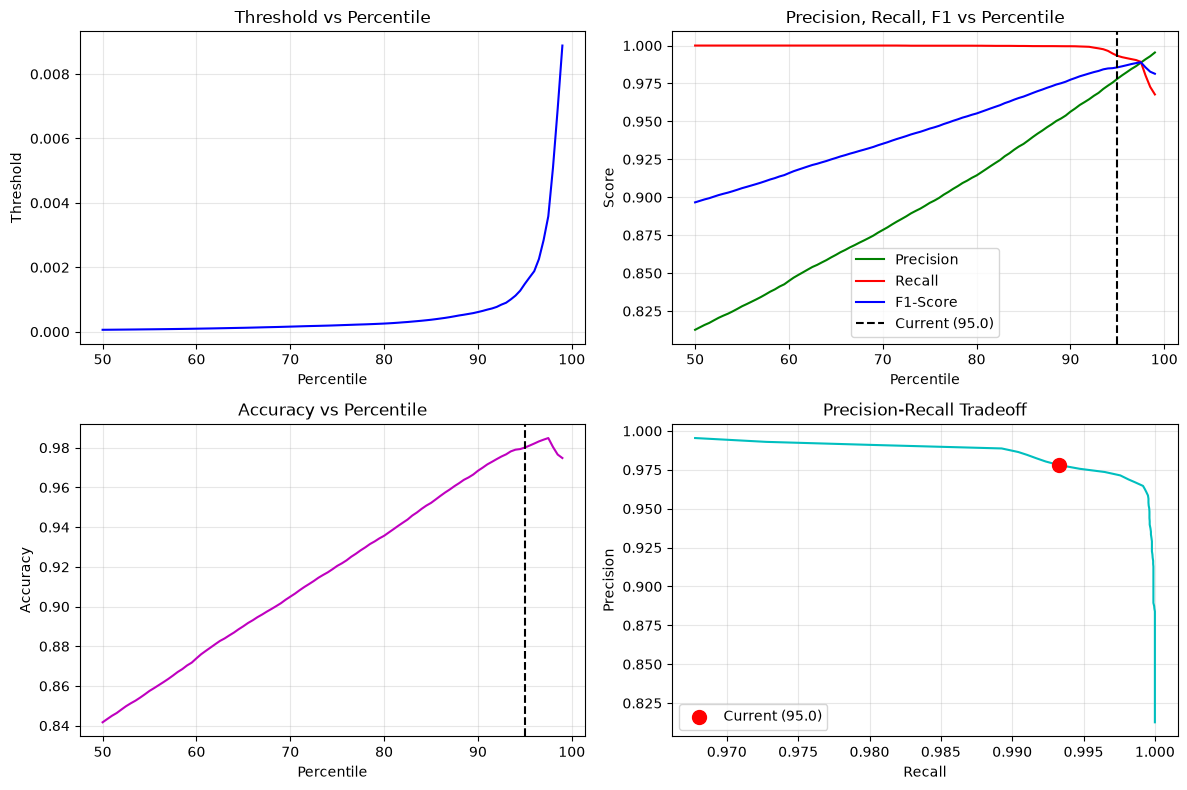


--- autoencoder_best_model_v1.keras ---


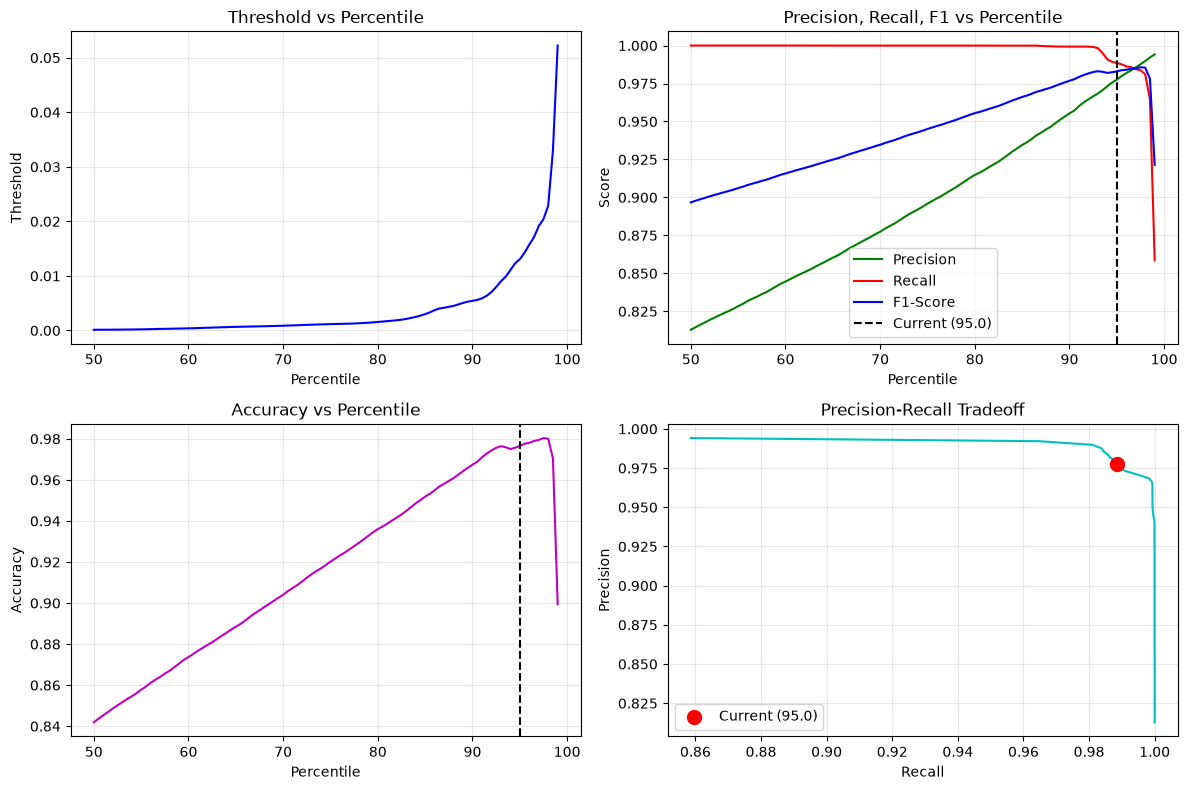


--- autoencoder_baseline_model.keras ---


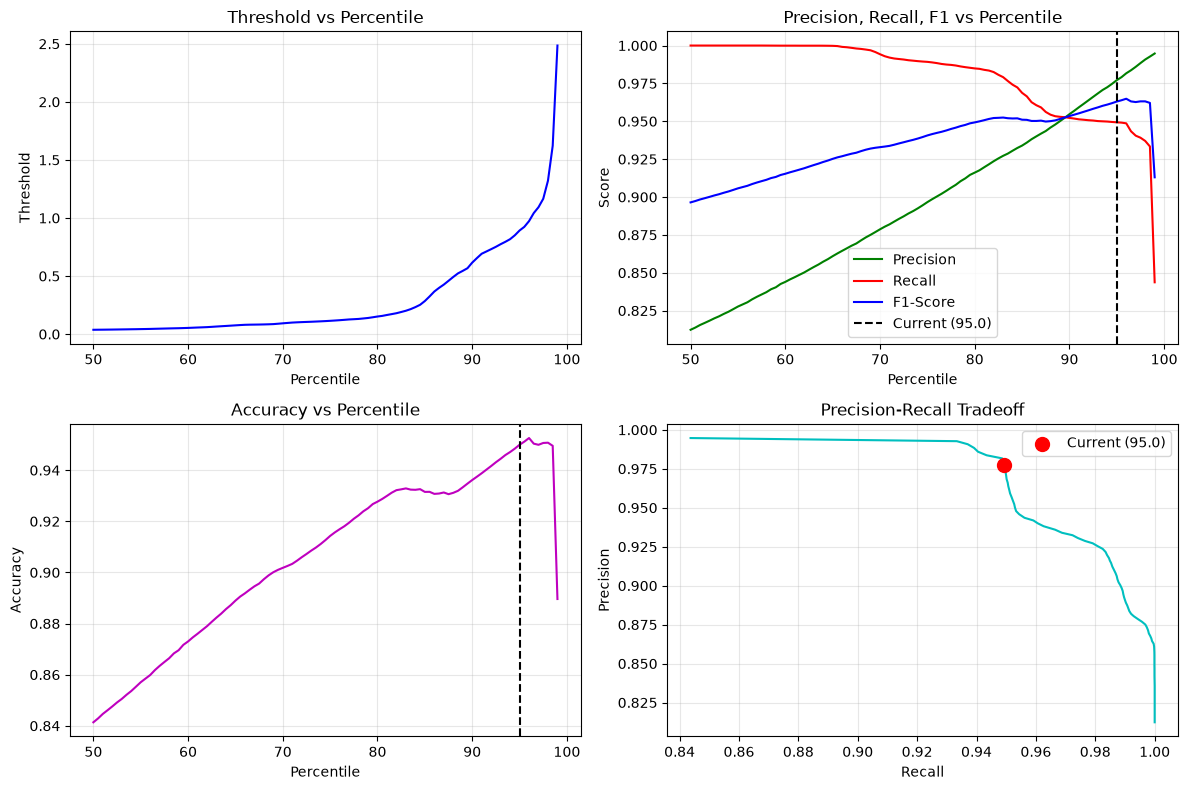

,model_name,best_f1_score,best_percentile,best_threshold,current_f1_score,current_percentile
0,autoencoder_best_model_v3.keras,0.988999,97.5,0.003587,0.985619,95.0
1,autoencoder_best_model_v2.keras,0.985721,98.0,0.017765,0.982435,95.0
2,autoencoder_best_model_v1.keras,0.985705,97.5,0.020418,0.983014,95.0
3,autoencoder_baseline_model.keras,0.964883,96.0,0.973024,0.963035,95.0


In [12]:
percentiles = np.arange(50, 99.5, 0.5)

print("Computing threshold sensitivity for all models...")
sensitivity_by_model = {}
for model_name, data in model_data.items():
    train_errors = data['train_errors']
    test_errors = data['test_errors']
    sensitivity_results = []
    for p in percentiles:
        thresh = select_anomaly_threshold(train_errors, percentile=p)
        y_pred_p = predict_anomalies(test_errors, thresh)
        m = compute_anomaly_metrics(y_test, y_pred_p)
        sensitivity_results.append({
            'percentile': p,
            'threshold': thresh,
            'accuracy': m['accuracy'],
            'precision': m['precision'],
            'recall': m['recall'],
            'f1_score': m['f1_score']
        })
    sensitivity_by_model[model_name] = pd.DataFrame(sensitivity_results)

# Single comparison figure: threshold/F1/accuracy vs percentile and the
# precision-recall tradeoff, one line per model in each subplot
plot_threshold_sensitivity_comparison(sensitivity_by_model, current_percentile=PERCENTILE)

# Individual full-size sensitivity plot for each model
for model_name, sdf in sensitivity_by_model.items():
    print(f"\n--- {model_name} ---")
    plot_threshold_sensitivity(sdf, current_percentile=PERCENTILE)

# Single summary table: best achievable F1-score (and its percentile) per model,
best_vs_current_rows = []
for model_name, sdf in sensitivity_by_model.items():
    best_row = sdf.loc[sdf['f1_score'].idxmax()]
    current_f1 = model_data[model_name]['metrics']['f1_score']
    best_vs_current_rows.append({
        'model_name': model_name,
        'best_f1_score': best_row['f1_score'],
        'best_percentile': best_row['percentile'],
        'best_threshold': best_row['threshold'],
        'current_f1_score': current_f1,
        'current_percentile': PERCENTILE,
    })

display(pd.DataFrame(best_vs_current_rows).sort_values('best_f1_score', ascending=False).reset_index(drop=True))